# Introduction to Data Analysis

**Module 4: Statistical Testing** | Lean Six Sigma Data Analytics

---

## Data-Based Testing of Ideas

One of the key principles of Lean Six Sigma is:

> **Data-based testing of ideas and improvements**
>
> (Also called "evidence-based improvement actions")

But what does this mean in practice? How do you do it?

In this introduction, you will learn:
1. How to model your **CTQ** and **influence factors**
2. Which **tools** to use for data-based testing
3. **When** these tools are applicable

---

## The Core Question

You analyze data when you want to know:

> **Are two different concepts related to each other?**

In a Lean Six Sigma project, you are asking:

> **Is my CTQ related to an influence factor?**

This happens in the **Improve phase** of DMAIC, where you want to:
- Establish the effect of an influence factor on your CTQ
- Develop and implement effective improvement actions

---

## Modeling CTQ and Influence Factors

```
┌─────────────────────┐         ┌─────────────────────┐
│   INFLUENCE FACTOR  │         │         CTQ         │
│         (X)         │  ────►  │         (Y)         │
│                     │         │                     │
│   What you can      │         │   What you want     │
│   control/change    │         │   to improve        │
└─────────────────────┘         └─────────────────────┘
```

Using data, you will test if this relationship exists or not.

---

## Example 1: Caffeine Percentage in Coffee

You want to know which factors determine the caffeine percentage level in coffee beans.

| Variable Type | Variable | Examples |
|---------------|----------|----------|
| **Y (CTQ)** | Caffeine Percentage | The outcome you want to improve |
| **X (Influence Factors)** | Number of extractions | Could affect caffeine level |
| | Duration of extraction | Could affect caffeine level |
| | Amount of solvent | Could affect caffeine level |

---

## Example 2: Hospital Length of Stay

You want to know which factors determine how long patients stay in the hospital.

| Variable Type | Variable | Examples |
|---------------|----------|----------|
| **Y (CTQ)** | Length of Stay | The outcome you want to improve |
| **X (Influence Factors)** | Type of appointment schedule | Could affect length of stay |
| | Age of patient | Could affect length of stay |
| | Type of surgery | Could affect length of stay |

---

## Choosing the Right Analysis Method

The suitable method depends on the **type of data** you have:
- Is your **CTQ (Y)** categorical or numerical?
- Is your **influence factor (X)** categorical or numerical?

```
                    INFLUENCE FACTOR (X)
                    
                  Numerical          Categorical
              ┌─────────────────┬─────────────────┐
              │                 │                 │
   Numerical  │   REGRESSION    │     ANOVA       │
              │                 │  (2-Sample T)   │
  C           │                 │  Kruskal-Wallis │
  T           ├─────────────────┼─────────────────┤
  Q           │                 │                 │
  (Y)         │    LOGISTIC     │   CHI-SQUARE    │
 Categorical  │   REGRESSION    │                 │
              │                 │                 │
              └─────────────────┴─────────────────┘
```

---

## Decision Tree: Which Method to Use?

```
                         START
                           │
                           ▼
                 ┌─────────────────┐
                 │  What type is   │
                 │   your Y (CTQ)? │
                 └────────┬────────┘
                          │
           ┌──────────────┴──────────────┐
           │                             │
           ▼                             ▼
      NUMERICAL                     CATEGORICAL
           │                             │
           ▼                             ▼
  ┌─────────────────┐           ┌─────────────────┐
  │  What type is   │           │  What type is   │
  │    your X?      │           │    your X?      │
  └────────┬────────┘           └────────┬────────┘
           │                             │
     ┌─────┴─────┐                 ┌─────┴─────┐
     │           │                 │           │
     ▼           ▼                 ▼           ▼
 NUMERICAL  CATEGORICAL       NUMERICAL  CATEGORICAL
     │           │                 │           │
     ▼           ▼                 ▼           ▼
┌─────────┐ ┌─────────┐      ┌──────────┐ ┌─────────┐
│REGRESSION│ │  ANOVA  │      │ LOGISTIC │ │CHI-SQUARE│
│         │ │         │      │REGRESSION│ │         │
└─────────┘ └─────────┘      └──────────┘ └─────────┘
                │
                ▼
         Special cases:
         • 2-Sample T-Test (2 groups)
         • Kruskal-Wallis (non-normal)
```

---

## Summary of Analysis Methods

| Y (CTQ) | X (Influence Factor) | Method | Notes |
|---------|---------------------|--------|-------|
| Numerical | Numerical | **Regression** | Continuous relationship |
| Numerical | Categorical | **ANOVA** | Compare group means |
| Numerical | Categorical (2 groups) | **2-Sample T-Test** | Special case of ANOVA |
| Numerical | Categorical (non-normal) | **Kruskal-Wallis** | Non-parametric alternative |
| Categorical | Numerical | **Logistic Regression** | Predict categories |
| Categorical | Categorical | **Chi-Square** | Test independence |

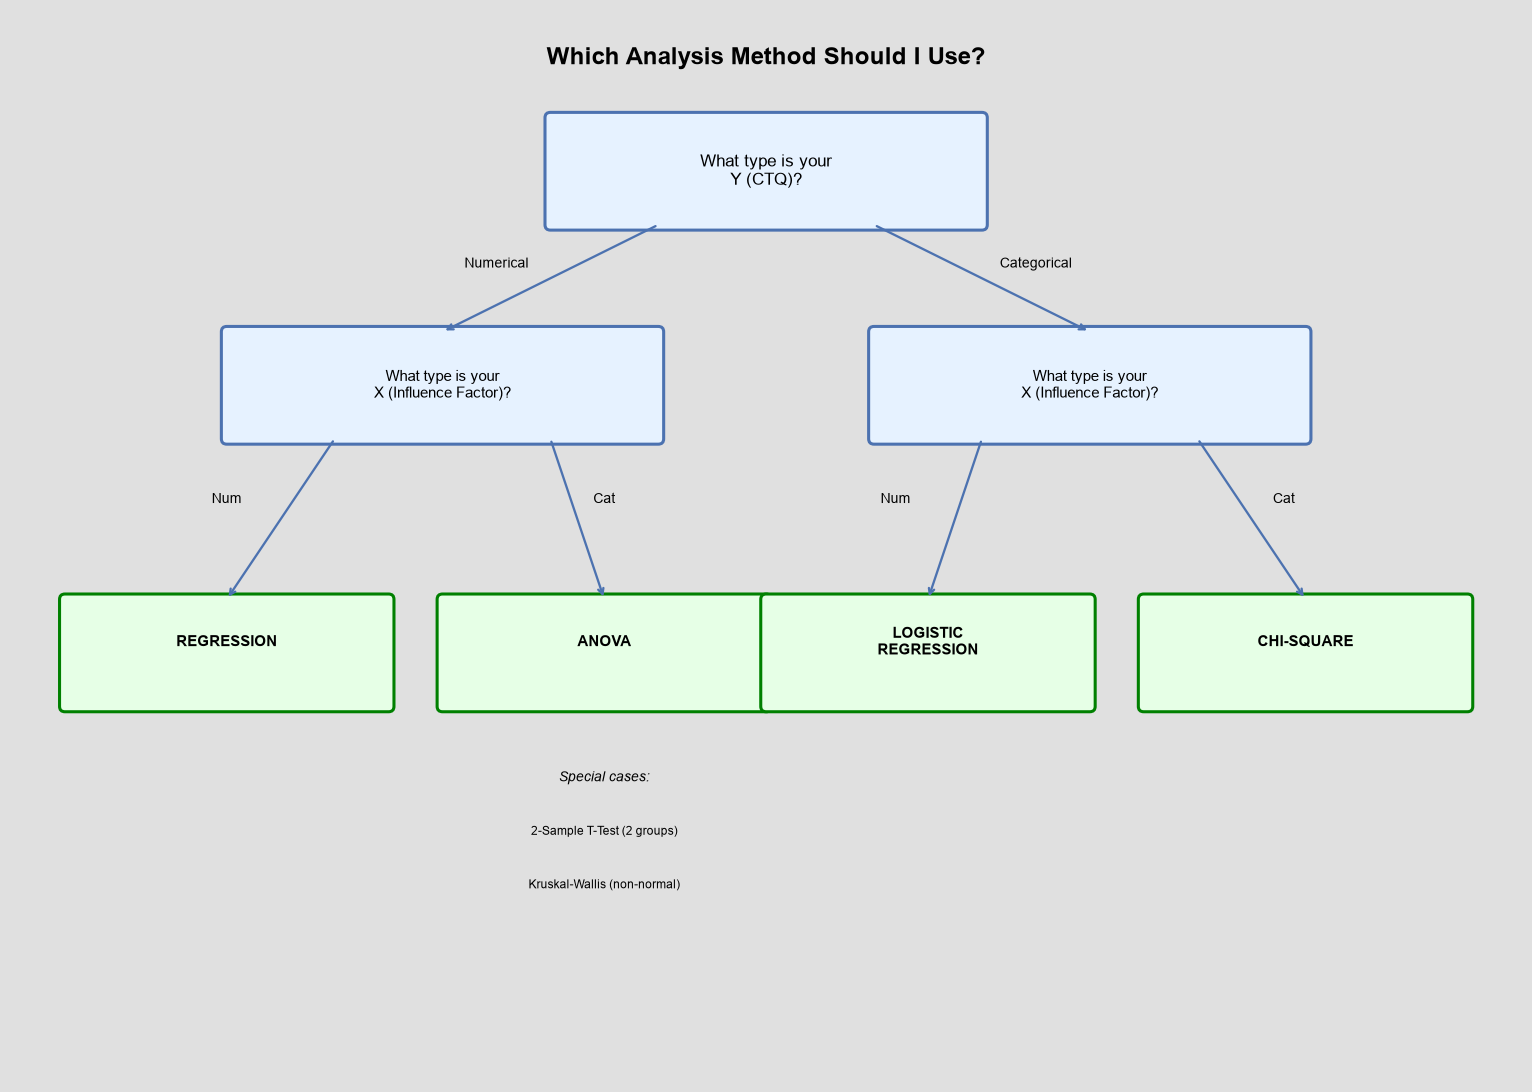

In [1]:
# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

# Visual decision tree
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# Colors
question_color = '#e6f2ff'
answer_color = '#fff2e6'
method_color = '#e6ffe6'

# Title
ax.text(7, 9.5, 'Which Analysis Method Should I Use?', ha='center', fontsize=16, fontweight='bold')

# Start: Y type question
rect = mpatches.FancyBboxPatch((5, 8), 4, 1, boxstyle='round,pad=0.05', 
                                facecolor=question_color, edgecolor=ms.HIST_EDGE, lw=2)
ax.add_patch(rect)
ax.text(7, 8.5, 'What type is your\nY (CTQ)?', ha='center', va='center', fontsize=11)

# Arrows from Y question
ax.annotate('', xy=(4, 7), xytext=(6, 8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(10, 7), xytext=(8, 8), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(4.5, 7.6, 'Numerical', fontsize=9, ha='center')
ax.text(9.5, 7.6, 'Categorical', fontsize=9, ha='center')

# Left branch: Y Numerical - X type question
rect = mpatches.FancyBboxPatch((2, 6), 4, 1, boxstyle='round,pad=0.05', 
                                facecolor=question_color, edgecolor=ms.HIST_EDGE, lw=2)
ax.add_patch(rect)
ax.text(4, 6.5, 'What type is your\nX (Influence Factor)?', ha='center', va='center', fontsize=10)

# Right branch: Y Categorical - X type question
rect = mpatches.FancyBboxPatch((8, 6), 4, 1, boxstyle='round,pad=0.05', 
                                facecolor=question_color, edgecolor=ms.HIST_EDGE, lw=2)
ax.add_patch(rect)
ax.text(10, 6.5, 'What type is your\nX (Influence Factor)?', ha='center', va='center', fontsize=10)

# Arrows from left X question
ax.annotate('', xy=(2, 4.5), xytext=(3, 6), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(5.5, 4.5), xytext=(5, 6), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(2, 5.4, 'Num', fontsize=9, ha='center')
ax.text(5.5, 5.4, 'Cat', fontsize=9, ha='center')

# Arrows from right X question
ax.annotate('', xy=(8.5, 4.5), xytext=(9, 6), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(12, 4.5), xytext=(11, 6), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.text(8.2, 5.4, 'Num', fontsize=9, ha='center')
ax.text(11.8, 5.4, 'Cat', fontsize=9, ha='center')

# Method boxes
methods = [
    (0.5, 3.5, 3, 1, 'REGRESSION', 'Y: Numerical\nX: Numerical'),
    (4, 3.5, 3, 1, 'ANOVA', 'Y: Numerical\nX: Categorical'),
    (7, 3.5, 3, 1, 'LOGISTIC\nREGRESSION', 'Y: Categorical\nX: Numerical'),
    (10.5, 3.5, 3, 1, 'CHI-SQUARE', 'Y: Categorical\nX: Categorical'),
]

for x, y, w, h, name, desc in methods:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05', 
                                    facecolor=method_color, edgecolor='green', lw=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + 0.1, name, ha='center', va='center', fontsize=10, fontweight='bold')

# ANOVA special cases
ax.text(5.5, 2.8, 'Special cases:', fontsize=9, ha='center', style='italic')
ax.text(5.5, 2.3, '2-Sample T-Test (2 groups)', fontsize=8, ha='center')
ax.text(5.5, 1.8, 'Kruskal-Wallis (non-normal)', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

---

## Steps for Data-Based Testing

1. **Identify your variables:**
   - Which variable is your **influence factor (X)**?
   - Which variable is your **CTQ (Y)**?

2. **Determine the data types:**
   - Is X **categorical** or **numerical**?
   - Is Y **categorical** or **numerical**?

3. **Select the appropriate method:**
   - Use the decision tree above

4. **Perform the analysis:**
   - Apply the method to your data
   - Interpret the results

---

## Key Takeaways

- **Data-based testing** means using data to verify if an influence factor affects your CTQ
- Model the relationship as: **X (Influence Factor) → Y (CTQ)**
- The **type of data** determines which analysis method to use:
  - Y Numerical + X Numerical → **Regression**
  - Y Numerical + X Categorical → **ANOVA** (or 2-Sample T, Kruskal-Wallis)
  - Y Categorical + X Numerical → **Logistic Regression**
  - Y Categorical + X Categorical → **Chi-Square**
- Use the **decision tree** to select the right method